In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# 윈도우 기준 한글 폰트 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

print("폰트 설정 완료!")

폰트 설정 완료!


In [2]:
df = pd.read_parquet('data/retail_preprocessed.parquet')

In [3]:
# ============================================================
# 0. 학습 구간 분할 
# ============================================================
CUTOFF = pd.Timestamp('2011-11-30') 
df_train = df[df['InvoiceDate'] < CUTOFF].copy()

# ============================================================
# 1. RFM 대상 모집단: 회원 + 유효 날짜
# ============================================================
base = df_train[
    df_train['Customer ID'].notna()
    & df_train['InvoiceDate'].notna()
].copy()

print(f"train 전체 행: {len(df_train):,}")
print(f"회원 거래 행: {len(base):,} "
      f"(비회원 제외 {len(df_train) - len(base):,})")

# ============================================================
# 2. Recency / Frequency: 정상 구매만 (전처리 플래그 재사용)
# ============================================================
purchase_df = base[base['is_purchase']].copy()

# 스냅샷은 분할 기준일로 고정 (구매 데이터 마지막 날 X)
snapshot = CUTOFF

rf = (
    purchase_df
    .groupby('Customer ID')
    .agg(
        Recency=(
            'InvoiceDate',
            lambda x: (snapshot - x.max()).days
        ),
        Frequency=('Invoice', 'nunique')
    )
)

# ============================================================
# 3. Monetary: 정상 구매 + 취소·반품 합산 순매출
# ============================================================
m = (
    base
    .groupby('Customer ID')
    .agg(Monetary=('Sales', 'sum'))
)

# ============================================================
# 4. 병합 (rf 기준 left join → 취소 전용 고객은 자동 제외)
# ============================================================
rfm = (
    rf
    .join(m, how='left')
    .reset_index()
)

# ============================================================
# 5. 순매출 비양수 고객 처리
# ============================================================
neg = rfm['Monetary'] <= 0
print(f"\n순매출 ≤ 0 고객: {neg.sum():,}명 "
      f"({neg.mean()*100:.2f}%)")
print(f"해당 고객 순매출 합계: {rfm.loc[neg, 'Monetary'].sum():,.0f}")

rfm = rfm[~neg].copy()

print(f"\n최종 RFM 고객 수: {len(rfm):,}")
print(rfm.describe().round(2))

train 전체 행: 774,690
회원 거래 행: 774,690 (비회원 제외 0)

순매출 ≤ 0 고객: 14명 (0.24%)
해당 고객 순매출 합계: -1,559

최종 RFM 고객 수: 5,807
       Recency  Frequency   Monetary
count  5807.00    5807.00    5807.00
mean    197.14       6.15    2743.56
std     205.23      12.51   13588.63
min       0.00       1.00       0.00
25%      23.00       1.00     328.28
50%      99.00       3.00     828.55
75%     369.50       7.00    2144.31
max     728.00     362.00  566923.10


RFM의 M축은 애초에 "양의 지출"을 전제하는 거라, Monetary ≤ 0 제외는 RFM 표준 처리

In [4]:
rfm['Frequency'].describe(
    percentiles=[0.90, 0.95, 0.99, 0.995, 0.999]
)

count    5807.000000
mean        6.148614
std        12.512734
min         1.000000
50%         3.000000
90%        13.000000
95%        20.000000
99%        45.000000
99.5%      66.970000
99.9%     160.044000
max       362.000000
Name: Frequency, dtype: float64

In [5]:
rfm.nlargest(
    10, 'Frequency'
)[['Customer ID', 'Recency', 'Frequency', 'Monetary']]

,Customer ID,Recency,Frequency,Monetary
2504,14911,1,362,250818.23
386,12748,0,313,45617.33
5382,17841,0,207,64695.41
2898,15311,0,204,110319.06
721,13089,1,199,105188.58
2207,14606,1,181,28400.29
5390,17850,362,155,50407.77
1764,14156,13,143,296745.26
2247,14646,6,142,511474.72
5635,18102,1,142,566923.10


In [6]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler

# Net Monetary가 양수인 고객만 군집화
rfm_all = rfm.copy()

rfm_cluster = rfm_all[
    rfm_all['Monetary'] > 0
].copy()

feature_names = ['Recency', 'Frequency', 'Monetary']

# 로그 변환
rfm_log = rfm_cluster[feature_names].apply(np.log1p)

print("로그 변환 후 왜도")
print(rfm_log.skew())

# 표준화
scaler = StandardScaler()

rfm_scaled = pd.DataFrame(
    scaler.fit_transform(rfm_log),
    columns=feature_names,
    index=rfm_cluster.index
)

# 식별용으로만 보관
rfm_scaled['Customer ID'] = rfm_cluster['Customer ID']

print("\n표준화 결과")
print(rfm_scaled[feature_names].describe().round(2))

print("\nMonetary 상위 고객")
print(
    rfm_cluster.nlargest(5, 'Monetary')[
        ['Customer ID', 'Recency', 'Frequency', 'Monetary']
    ]
)

로그 변환 후 왜도
Recency     -0.614971
Frequency    1.010154
Monetary     0.154678
dtype: float64

표준화 결과
       Recency  Frequency  Monetary
count  5807.00    5807.00   5807.00
mean      0.00      -0.00     -0.00
std       1.00       1.00      1.00
min      -2.70      -1.05     -4.88
25%      -0.75      -1.05     -0.70
50%       0.13      -0.19     -0.03
75%       0.93       0.68      0.65
max       1.35       5.42      4.68

Monetary 상위 고객
     Customer ID  Recency  Frequency   Monetary
5635       18102        1        142  566923.10
2247       14646        6        142  511474.72
1764       14156       13        143  296745.26
2504       14911        1        362  250818.23
5000       17450        0         50  232081.51


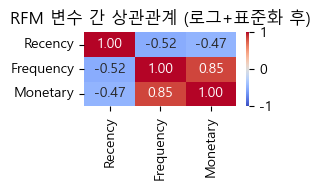

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(3,2))
sns.heatmap(
    rfm_scaled[feature_names].corr(),
    vmin=-1, vmax=1,          # 음의 상관 표시 필수
    annot=True, fmt='.2f',
    cmap='coolwarm', center=0
)
plt.title('RFM 변수 간 상관관계 (로그+표준화 후)')
plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import pandas as pd

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans


# ============================================================
# 0. 기본 설정
# ============================================================

RANDOM_STATE = 42
EPSILON = 1e-8

required_cols = [
    'Invoice',
    'InvoiceDate',
    'Customer ID',
    'Quantity',
    'Price',
    'Sales'
]

missing_cols = [
    col for col in required_cols
    if col not in df_train.columns
]

if missing_cols:
    raise ValueError(
        f"df_train에 필요한 칼럼이 없습니다: {missing_cols}"
    )


# ============================================================
# 1. 거래 데이터 준비
# ============================================================
tx = df_train[required_cols].copy()

tx['Invoice'] = (
    tx['Invoice']
    .astype(str)
    .str.strip()
)

tx['InvoiceDate'] = pd.to_datetime(
    tx['InvoiceDate'],
    errors='coerce'
)

tx['Quantity'] = pd.to_numeric(
    tx['Quantity'],
    errors='coerce'
)

tx['Price'] = pd.to_numeric(
    tx['Price'],
    errors='coerce'
)

tx['Sales'] = pd.to_numeric(
    tx['Sales'],
    errors='coerce'
)

tx = tx.dropna(
    subset=[
        'InvoiceDate',
        'Customer ID',
        'Quantity',
        'Price',
        'Sales'
    ]
).copy()

# 고객 ID 표현 통일
tx['Customer ID'] = (
    tx['Customer ID']
    .astype(str)
)

# 월 단위
tx['YearMonth'] = (
    tx['InvoiceDate']
    .dt.to_period('M')
)

# 정상 구매 여부
tx['is_purchase'] = (
    ~tx['Invoice'].str.startswith('C')
    & (tx['Quantity'] > 0)
)

print("거래 데이터 준비 완료")
print("거래 행 수:", len(tx))
print("고객 수:", tx['Customer ID'].nunique())
print(
    "기간:",
    tx['InvoiceDate'].min(),
    "~",
    tx['InvoiceDate'].max()
)


# ============================================================
# 2. 고객 × 월 순매출 및 순수량 집계
# ============================================================
monthly_net = (
    tx
    .groupby(
        ['Customer ID', 'YearMonth'],
        as_index=False
    )
    .agg(
        monthly_sales=('Sales', 'sum'),
        monthly_quantity=('Quantity', 'sum')
    )
)

# 화폐 및 수량 계산 오차 정리
monthly_net['monthly_sales'] = (
    monthly_net['monthly_sales']
    .round(2)
)

monthly_net['monthly_quantity'] = (
    monthly_net['monthly_quantity']
    .round(6)
)

monthly_net['monthly_sales'] = (
    monthly_net['monthly_sales']
    .mask(
        monthly_net['monthly_sales'].abs() < EPSILON,
        0
    )
)

monthly_net['monthly_quantity'] = (
    monthly_net['monthly_quantity']
    .mask(
        monthly_net['monthly_quantity'].abs() < EPSILON,
        0
    )
)


# ============================================================
# 3. 정상 구매 기준 월별 주문 횟수와 마지막 구매일
# ============================================================
purchase_tx = tx[
    tx['is_purchase']
].copy()

if purchase_tx.empty:
    raise ValueError(
        "정상 구매 거래가 없습니다."
    )

monthly_purchase = (
    purchase_tx
    .groupby(
        ['Customer ID', 'YearMonth'],
        as_index=False
    )
    .agg(
        monthly_orders=('Invoice', 'nunique'),
        monthly_last_purchase=('InvoiceDate', 'max')
    )
)

monthly = monthly_net.merge(
    monthly_purchase,
    on=['Customer ID', 'YearMonth'],
    how='left',
    validate='one_to_one'
)

monthly['monthly_orders'] = (
    monthly['monthly_orders']
    .fillna(0)
    .astype(int)
)


# ============================================================
# 4. 고객별 최초 구매월부터 마지막 관측월까지 패널 생성
# ============================================================
first_purchase_month = (
    purchase_tx
    .groupby('Customer ID')['YearMonth']
    .min()
)

last_observed_month = (
    tx['YearMonth']
    .max()
)

panel_parts = []

# 고객별 최초 구매월부터 데이터 마지막 관측월까지 모든 달을 빈칸 없이 채웁니다. 한 번 사면 그 뒤로는 구매가 없어도 매달 계속 행이 생깁니다.
for customer_id, start_month in first_purchase_month.items():

    customer_months = pd.period_range(
        start=start_month,
        end=last_observed_month,
        freq='M'
    )

    customer_panel = pd.DataFrame({
        'Customer ID': customer_id,
        'YearMonth': customer_months
    })

    panel_parts.append(customer_panel)

panel = pd.concat(
    panel_parts,
    ignore_index=True
)

panel = panel.merge(
    monthly,
    on=['Customer ID', 'YearMonth'],
    how='left',
    validate='one_to_one'
)

fill_zero_cols = [
    'monthly_sales',
    'monthly_quantity',
    'monthly_orders'
]

panel[fill_zero_cols] = (
    panel[fill_zero_cols]
    .fillna(0)
)

panel['monthly_sales'] = (
    panel['monthly_sales']
    .round(2)
)

panel['monthly_quantity'] = (
    panel['monthly_quantity']
    .round(6)
)

panel['monthly_orders'] = (
    panel['monthly_orders']
    .astype(int)
)

panel = (
    panel
    .sort_values(
        ['Customer ID', 'YearMonth']
    )
    .reset_index(drop=True)
)


# ============================================================
# 5. Recency 계산
# ============================================================
panel['last_purchase_date'] = (
    panel
    .groupby('Customer ID')[
        'monthly_last_purchase'
    ]
    .ffill()
)

# 날짜와 시간을 날짜 단위로 통일
panel['last_purchase_date'] = (
    pd.to_datetime(
        panel['last_purchase_date'],
        errors='coerce'
    )
    .dt.normalize()
)

panel['month_end'] = (
    panel['YearMonth']
    .dt.to_timestamp(how='end')
    .dt.normalize()
)

panel['Recency'] = (
    panel['month_end']
    - panel['last_purchase_date']
).dt.days

negative_recency_count = (
    panel['Recency']
    .dropna()
    .lt(0)
    .sum()
)

if negative_recency_count > 0:
    raise ValueError(
        f"음수 Recency가 {negative_recency_count}건 있습니다."
    )


# ============================================================
# 6. 누적 Frequency 및 Monetary 계산
# ============================================================
panel['Frequency'] = (
    panel
    .groupby('Customer ID')[
        'monthly_orders'
    ]
    .cumsum()
)

panel['Monetary'] = (
    panel
    .groupby('Customer ID')[
        'monthly_sales'
    ]
    .cumsum()
    .round(2)
)

# 사실상 0인 부동소수점 오차 제거
panel['Monetary'] = (
    panel['Monetary']
    .mask(
        panel['Monetary'].abs() < EPSILON,
        0
    )
)

print("\nMonetary 최소값:")
print(panel['Monetary'].min())

print(
    "사실상 0인 Monetary 수:",
    (panel['Monetary'].abs() < EPSILON).sum()
)


# ============================================================
# 7. 월별 행동 변수 생성
# ============================================================
customer_group = panel.groupby(
    'Customer ID',
    group_keys=False
)

# YearMonth가 2010-06일 경우:
# lag_1 = 2010-06
# lag_2 = 2010-05
# lag_3 = 2010-04

panel['sales_m0'] = (
    panel['monthly_sales']
)

panel['sales_m1'] = (
    customer_group['monthly_sales']
    .shift(1)
)

panel['sales_m2'] = (
    customer_group['monthly_sales']
    .shift(2)
)

panel['orders_m0'] = (
    panel['monthly_orders']
)

panel['orders_m1'] = (
    customer_group['monthly_orders']
    .shift(1)
)

panel['orders_m2'] = (
    customer_group['monthly_orders']
    .shift(2)
)

panel['quantity_m0'] = (
    panel['monthly_quantity']
)


# ============================================================
# 8. 고객 활동 기간과 계절 변수
# ============================================================
panel['first_purchase_month'] = (
    panel
    .groupby('Customer ID')[
        'YearMonth'
    ]
    .transform('min')
)

panel['customer_tenure'] = (
    (
        panel['YearMonth'].dt.year
        - panel['first_purchase_month'].dt.year
    ) * 12
    +
    (
        panel['YearMonth'].dt.month
        - panel['first_purchase_month'].dt.month
    )
)

panel['month'] = (
    panel['YearMonth']
    .dt.month
)


# ============================================================
# 8.5 파생 피처 (as-of, 누수 없음)
#     주문 단위 4종은 purchase_tx(정상구매)에서 재집계
# ============================================================

# ── (a) 주문(Invoice) 단위 테이블 ──
orders = (
    purchase_tx
    .groupby(['Customer ID', 'Invoice'], as_index=False)
    .agg(
        order_amount=('Sales', 'sum'),
        order_qty=('Quantity', 'sum'),
        order_date=('InvoiceDate', 'max'),
    )
)
orders['YearMonth'] = orders['order_date'].dt.to_period('M')

# ── (b) 고객 x 월 주문 집계 (last = 그 달 마지막 주문) ──
orders = orders.sort_values(['Customer ID', 'order_date', 'Invoice'])
om = (
    orders
    .groupby(['Customer ID', 'YearMonth'])
    .agg(
        m_cnt=('order_amount', 'size'),
        m_sum=('order_amount', 'sum'),
        m_sqsum=('order_amount', lambda s: (s ** 2).sum()),
        m_max=('order_amount', 'max'),
        m_last=('order_amount', 'last'),
        m_qty=('order_qty', 'sum'),
    )
    .reset_index()
)

panel = panel.merge(om, on=['Customer ID', 'YearMonth'], how='left')

for c in ['m_cnt', 'm_sum', 'm_sqsum', 'm_qty']:
    panel[c] = panel[c].fillna(0)

g = panel.groupby('Customer ID', group_keys=False)

# 누적 통계
panel['cum_cnt']   = g['m_cnt'].cumsum()
panel['cum_qty']   = g['m_qty'].cumsum()
panel['cum_sum']   = g['m_sum'].cumsum()
panel['cum_sqsum'] = g['m_sqsum'].cumsum()

# ── (1) 평균 주문금액 = 누적 순매출 / 누적 주문수 ──
panel['avg_order_value'] = np.where(
    panel['Frequency'] > 0,
    panel['Monetary'] / panel['Frequency'],
    0
).round(2)

# ── (2) 최근 30일 / 90일 매출 (캘린더 월 근사) ──
panel['sales_30d'] = panel['sales_m0'].round(2)
panel['sales_90d'] = (
    panel['sales_m0']
    + panel['sales_m1'].fillna(0)
    + panel['sales_m2'].fillna(0)
).round(2)

# ── (3) 최근 주문금액 (그 달 마지막 주문, 빈 달은 직전값 유지) ──
panel['last_order_value'] = (
    panel.groupby('Customer ID')['m_last'].ffill().round(2)
)

# ── (4) 최대 주문금액 (as-of 누적 max) ──
panel['max_order_value'] = g['m_max'].cummax()
panel['max_order_value'] = (
    panel.groupby('Customer ID')['max_order_value'].ffill().round(2)
)

# ── (5) 주문금액 표준편차 (표본, 주문 2건 미만이면 0) ──
n = panel['cum_cnt']
var = (
    (panel['cum_sqsum'] - panel['cum_sum'] ** 2 / n.replace(0, np.nan))
    / (n - 1).replace(0, np.nan)
)
panel['std_order_value'] = (
    np.sqrt(var.clip(lower=0)).where(n >= 2, 0).round(2)
)

# ── (6) 최근 매출 추세 = 이번달 - 지난달 ──
panel['sales_trend_1m'] = (
    panel['sales_m0'] - panel['sales_m1'].fillna(0)
).round(2)

# ── (7) 평균 구매수량 = 누적 수량 / 누적 주문수 ──
panel['avg_purchase_qty'] = np.where(
    panel['cum_cnt'] > 0,
    panel['cum_qty'] / panel['cum_cnt'],
    0
).round(4)

# ── (8) 활동기간당 매출 = 누적 순매출 / (tenure+1) ──
panel['sales_per_tenure'] = (
    panel['Monetary'] / (panel['customer_tenure'] + 1)
).round(2)

# ── (9) 취소 주문 건수 (C-인보이스 수, 취소가 발생한 달 기준 → as-of) ──
mc = (
    tx[tx['Invoice'].str.startswith('C')]
    .groupby(['Customer ID', 'YearMonth'], as_index=False)
    .agg(cancel_m0=('Invoice', 'nunique'))
)

panel = panel.merge(
    mc,
    on=['Customer ID', 'YearMonth'],
    how='left',
    validate='one_to_one'
)
panel['cancel_m0'] = panel['cancel_m0'].fillna(0).astype(int)

# 누적 취소 건수 (Frequency와 같은 cumsum 방식)
panel['cancel_cnt'] = (
    panel.groupby('Customer ID')['cancel_m0'].cumsum()
)
# 중간 재료 제거
panel = panel.drop(columns=[
    'm_cnt', 'm_sum', 'm_sqsum', 'm_max', 'm_last', 'm_qty',
    'cum_cnt', 'cum_qty', 'cum_sum', 'cum_sqsum',
])


# ============================================================
# 9. 다음 달 타깃 생성
# ============================================================
customer_group = panel.groupby(
    'Customer ID',
    group_keys=False
)

panel['target_next_sales'] = (
    customer_group['monthly_sales']
    .shift(-1)
)#각 고객의 다음 달 매출을 현재 행으로 끌어오는 코드

panel['next_month_orders'] = (
    customer_group['monthly_orders']
    .shift(-1)
)

panel['target_next_purchase'] = np.where(
    panel['next_month_orders'].isna(),
    np.nan,
    (
        panel['next_month_orders'] > 0
    ).astype(int)
)

# 다음 달 정답이 없는 마지막 관측월 제거
panel_model = panel[
    panel['target_next_sales'].notna()
].copy()

panel_model['target_next_sales'] = (
    panel_model['target_next_sales']
    .round(2)
)

panel_model['target_next_purchase'] = (
    panel_model['target_next_purchase']
    .astype(int)
)

거래 데이터 준비 완료
거래 행 수: 774690
고객 수: 5844
기간: 2009-12-01 07:45:00 ~ 2011-11-29 18:19:00

Monetary 최소값:
-1663.06
사실상 0인 Monetary 수: 222


In [9]:
print("패널 행 수:", len(panel_model))
print("고객 수:", panel_model['Customer ID'].nunique())
print("기간:", panel_model['YearMonth'].min(), "~", panel_model['YearMonth'].max())
print("2011-08 행 수:", (panel_model['YearMonth'] == pd.Period('2011-08','M')).sum())

패널 행 수: 86300
고객 수: 5633
기간: 2009-12 ~ 2011-10
2011-08 행 수: 5224


In [10]:
# ============================================================
# 10. RFM 군집화 대상 생성
# ============================================================
segment_features = [
    'Recency',
    'Frequency',
    'Monetary'
]

segment_mask = (
    panel_model[segment_features]
    .notna()
    .all(axis=1)
    & (panel_model['Recency'] >= 0)
    & (panel_model['Frequency'] > 0)
    & (panel_model['Monetary'] > EPSILON)
)

segment_data = (
    panel_model
    .loc[
        segment_mask,
        segment_features
    ]
    .astype(float)
    .copy()
)


print("\nRFM 군집화 대상")
print("대상 행 수:", len(segment_data))
print(segment_data.describe().round(2))


# ── 로그변환 + fit(2011-08 단면) / predict(패널 전체) ──
SEG_FIT_LAST = pd.Period('2011-10', 'M')
fit_mask = segment_mask & (panel_model['YearMonth'] == SEG_FIT_LAST)

seg_all = np.log1p(panel_model.loc[segment_mask, segment_features].astype(float))
seg_fit = np.log1p(panel_model.loc[fit_mask,     segment_features].astype(float))

# 유한값 검증 (기존 로직 유지, seg_all 대상)
if not np.isfinite(seg_all.to_numpy(dtype=float)).all():
    raise ValueError("RFM 로그 데이터에 NaN/무한값이 있습니다.")

print("로그 변환 후 왜도\n", seg_fit.skew())

segment_scaler = StandardScaler().fit(seg_fit)

# ★ 진단과 학습이 공유하는 단 하나의 행렬
X_FIT = segment_scaler.transform(seg_fit)
X_ALL = segment_scaler.transform(seg_all)

print(f"fit 행 수: {X_FIT.shape[0]:,}  |  predict 대상: {X_ALL.shape[0]:,}")


RFM 군집화 대상
대상 행 수: 86027
        Recency  Frequency   Monetary
count  86027.00   86027.00   86027.00
mean     131.32       4.52    2001.53
std      136.24       8.77    9380.48
min        0.00       1.00       1.15
25%       27.00       1.00     286.95
50%       81.00       2.00     638.20
75%      196.00       5.00    1599.12
max      699.00     330.00  551592.02
로그 변환 후 왜도
 Recency     -0.734803
Frequency    1.036645
Monetary     0.253814
dtype: float64
fit 행 수: 5,619  |  predict 대상: 86,027


In [11]:
raw_fit = panel_model.loc[fit_mask, segment_features].astype(float)
print("로그 변환 전 왜도\n", raw_fit.skew().round(4))
print("\n로그 변환 후 왜도\n", seg_fit.skew().round(4))

로그 변환 전 왜도
 Recency       0.7834
Frequency    11.2457
Monetary     26.9512
dtype: float64

로그 변환 후 왜도
 Recency     -0.7348
Frequency    1.0366
Monetary     0.2538
dtype: float64


In [12]:
# ============================================================
# 19-B. k 진단 — X_FIT (학습에 쓰는 바로 그 행렬)
# ============================================================
from sklearn.metrics import (silhouette_score, davies_bouldin_score,
                             adjusted_rand_score)
from kneed import KneeLocator

K_RANGE, N_BOOT, SUB_FRAC = list(range(2, 11)), 10, 0.8
n = len(X_FIT)

rows = []
for k in K_RANGE:
    km = KMeans(k, random_state=RANDOM_STATE, n_init=10).fit(X_FIT)
    rows.append({'k': k, 'inertia': km.inertia_,
                 'silhouette': silhouette_score(X_FIT, km.labels_),
                 'davies_bouldin': davies_bouldin_score(X_FIT, km.labels_),
                 'min_share': np.bincount(km.labels_).min() / n})
metrics = pd.DataFrame(rows).set_index('k')

rng = np.random.default_rng(RANDOM_STATE)

# elbow 안정성
elbows = []
for _ in range(N_BOOT):
    idx = rng.choice(n, int(n * SUB_FRAC), replace=False)
    ins = [KMeans(k, random_state=RANDOM_STATE, n_init=10).fit(X_FIT[idx]).inertia_
           for k in K_RANGE]
    elbows.append(KneeLocator(K_RANGE, ins, curve='convex',
                              direction='decreasing').elbow)
elbow_dist = pd.Series(elbows, dtype='object').value_counts(normalize=True).sort_index()

# 군집 안정성 (ARI)
for k in K_RANGE:
    s = []
    for _ in range(N_BOOT):
        i1 = rng.choice(n, int(n * SUB_FRAC), replace=False)
        i2 = rng.choice(n, int(n * SUB_FRAC), replace=False)
        common = np.intersect1d(i1, i2)
        km1 = KMeans(k, random_state=RANDOM_STATE, n_init=10).fit(X_FIT[i1])
        km2 = KMeans(k, random_state=RANDOM_STATE, n_init=10).fit(X_FIT[i2])
        s.append(adjusted_rand_score(km1.predict(X_FIT[common]),
                                     km2.predict(X_FIT[common])))
    metrics.loc[k, 'stability_ari'] = np.mean(s)

sil = metrics['silhouette'].to_numpy()
peaks = [K_RANGE[i] for i in range(1, len(sil) - 1)
         if sil[i] > sil[i-1] and sil[i] > sil[i+1]]

print(metrics.round(4))
print('\n부트스트랩 elbow 분포:\n', elbow_dist.round(3))
print(f"\nsilhouette argmax  : {metrics['silhouette'].idxmax()}")
print(f"silhouette 국소최대: {peaks}")
print(f"davies_bouldin 최소: {metrics['davies_bouldin'].idxmin()}")
print(f"stability 최대     : {metrics['stability_ari'].idxmax()}")

metrics.round(4).to_csv('data/processed/k_diagnostics.csv')

      inertia  silhouette  davies_bouldin  min_share  stability_ari
k                                                                  
2   8435.1457      0.4397          0.8855     0.3807         0.9791
3   6394.8255      0.3451          1.0708     0.1933         0.9667
4   4790.6358      0.3743          0.9131     0.1838         0.9687
5   4025.9611      0.3427          0.9612     0.0835         0.9740
6   3518.7137      0.3389          0.9629     0.0715         0.9467
7   3165.5024      0.2930          1.0132     0.0626         0.9200
8   2885.0271      0.2929          1.0016     0.0523         0.8072
9   2658.1797      0.2969          0.9828     0.0397         0.8823
10  2460.2305      0.2832          1.0016     0.0374         0.9288

부트스트랩 elbow 분포:
 4    0.1
5    0.9
Name: proportion, dtype: float64

silhouette argmax  : 2
silhouette 국소최대: [4, 9]
davies_bouldin 최소: 2
stability 최대     : 2


k= 3 | inertia=   6394.8 | silhouette=0.3451
k= 4 | inertia=   4790.6 | silhouette=0.3743
k= 5 | inertia=   4026.0 | silhouette=0.3427
k= 6 | inertia=   3518.7 | silhouette=0.3389
k= 7 | inertia=   3165.5 | silhouette=0.2930
k= 8 | inertia=   2885.0 | silhouette=0.2929
k= 9 | inertia=   2658.2 | silhouette=0.2969
k=10 | inertia=   2460.2 | silhouette=0.2832

=== k 복합 점수 (W_SIL = 0.50) ===
    inertia  silhouette  sil_norm  elbow_norm  composite
k                                                       
3    6394.8      0.3451     0.679       0.000      0.339
4    4790.6      0.3743     1.000       0.837      0.919
5    4026.0      0.3427     0.653       1.000      0.827
6    3518.7      0.3389     0.612       0.956      0.784
7    3165.5      0.2930     0.108       0.788      0.448
8    2885.0      0.2929     0.106       0.562      0.334
9    2658.2      0.2969     0.150       0.293      0.221
10   2460.2      0.2832     0.000       0.000      0.000

Elbow 기준 k     : 5
Silhouette argmax:

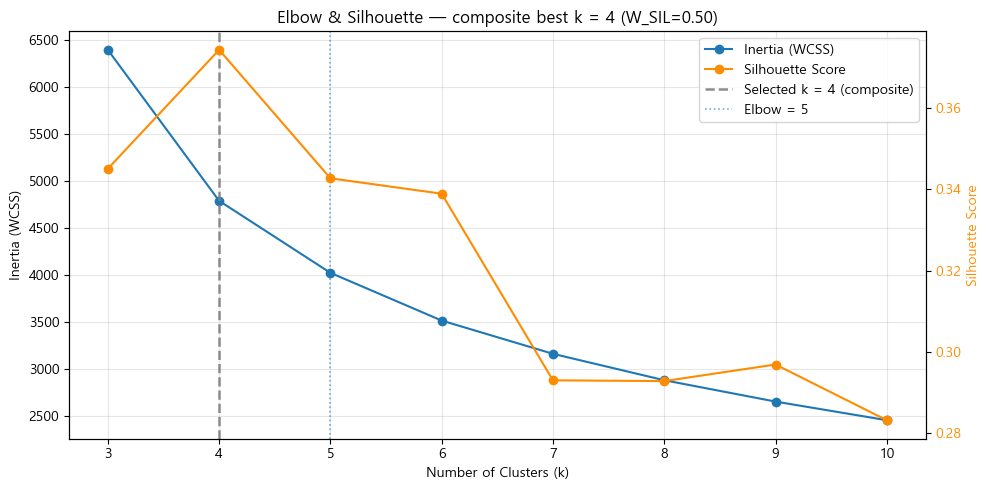

In [13]:
# ============================================================
# 19-B'. Elbow + Silhouette 복합 기준으로 k 자동 산출
#   · 두 지표를 [0,1]로 정규화해 가중합 → argmax를 best_k로 채택
#   · best_k는 "진단 결과"일 뿐이며, 실제 k 확정은 19-C의 N_CLUSTERS
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from kneed import KneeLocator

X = X_FIT                    # ← rfm_scaled_k[feature_names] 대신
k_range = list(range(3, 11))

# 실루엣 가중치 (0 = 엘보만 반영, 1 = 실루엣만 반영)
W_SIL = 0.5

inertias = []
silhouettes = []

# =========================
# K별 평가
# =========================
for k in k_range:
    km = KMeans(
        n_clusters=k,      # 루프 변수 사용
        random_state=42,
        n_init=10
    )

    labels = km.fit_predict(X)

    inertias.append(km.inertia_)
    silhouettes.append(
        silhouette_score(X, labels)
    )

    print(
        f"k={k:2d} | "
        f"inertia={km.inertia_:9.1f} | "
        f"silhouette={silhouettes[-1]:.4f}"
    )

inertias = np.asarray(inertias, dtype=float)
silhouettes = np.asarray(silhouettes, dtype=float)

# =========================
# 개별 기준
# =========================
knee = KneeLocator(
    k_range,
    inertias.tolist(),
    curve='convex',
    direction='decreasing'
)

elbow_k = knee.elbow
silhouette_k = k_range[int(np.argmax(silhouettes))]

# =========================
# 복합 점수로 best_k 산출
# =========================
def _minmax(v):
    """[0,1] 정규화. 전 구간이 동일하면 0으로 반환."""
    v = np.asarray(v, dtype=float)
    span = v.max() - v.min()
    return np.zeros_like(v) if span == 0 else (v - v.min()) / span


# (1) 실루엣: 클수록 좋음 → 그대로 정규화
sil_norm = _minmax(silhouettes)

# (2) 엘보 강도: (k, inertia)를 [0,1]로 옮긴 뒤,
#     양 끝점을 잇는 직선 대비 곡선이 아래로 꺼진 깊이 = 꺾임의 세기.
#     inertia는 볼록 감소이므로 이 값은 항상 0 이상이고,
#     최대가 되는 지점이 곧 무릎(knee)이다.
x_norm = _minmax(np.asarray(k_range, dtype=float))
y_norm = _minmax(inertias)
elbow_gap = (1 - x_norm) - y_norm
elbow_norm = _minmax(elbow_gap)

# (3) 가중합
composite = W_SIL * sil_norm + (1 - W_SIL) * elbow_norm
best_k = k_range[int(np.argmax(composite))]

k_score = pd.DataFrame({
    'inertia': inertias.round(1),
    'silhouette': silhouettes.round(4),
    'sil_norm': sil_norm.round(3),
    'elbow_norm': elbow_norm.round(3),
    'composite': composite.round(3),
}, index=pd.Index(k_range, name='k'))

print("\n=== k 복합 점수 (W_SIL = %.2f) ===" % W_SIL)
print(k_score)

print(f"\nElbow 기준 k     : {elbow_k}")
print(f"Silhouette argmax: {silhouette_k}")
print(f"복합 기준 best_k : {best_k}")

# =========================
# 가중치 민감도 — best_k가 W_SIL 설정에 얼마나 휘둘리는지
# =========================
_ws = np.linspace(0, 1, 101)
_win = [k_range[int(np.argmax(w * sil_norm + (1 - w) * elbow_norm))] for w in _ws]

_segs = []
for w, kw in zip(_ws, _win):
    if _segs and _segs[-1][2] == kw:
        _segs[-1][1] = w
    else:
        _segs.append([w, w, kw])

print("\n=== W_SIL 민감도 ===")
for a, b, kw in _segs:
    mark = '  ←현재' if a <= W_SIL <= b else ''
    print(f"  W_SIL {a:.2f}~{b:.2f} → k={kw}{mark}")

print("\n※ best_k는 진단값입니다. 최종 k는 19-C의 N_CLUSTERS에서 확정하세요.")


# =========================
# 하나의 그래프에 표시
# =========================
fig, ax1 = plt.subplots(figsize=(10, 5))

# Elbow / Inertia
line1 = ax1.plot(
    k_range,
    inertias,
    'o-',
    label='Inertia (WCSS)'
)

ax1.set_xlabel('Number of Clusters (k)')
ax1.set_ylabel('Inertia (WCSS)')
ax1.set_xticks(k_range)
ax1.grid(alpha=0.3)

# 오른쪽 y축 생성
ax2 = ax1.twinx()

# Silhouette - 주황색
line2 = ax2.plot(
    k_range,
    silhouettes,
    'o-',
    color='darkorange',
    label='Silhouette Score'
)

ax2.set_ylabel(
    'Silhouette Score',
    color='darkorange'
)

ax2.tick_params(
    axis='y',
    labelcolor='darkorange'
)

# 복합 기준 선택 k — 점선
vlines = [ax1.axvline(
    best_k,
    linestyle='--',
    color='gray',
    linewidth=1.8,
    alpha=0.9,
    label=f'Selected k = {best_k} (composite)'
)]

# 개별 기준이 복합 기준과 다를 때만 옅게 함께 표시
if elbow_k is not None and elbow_k != best_k:
    vlines.append(ax1.axvline(
        elbow_k, linestyle=':', color='tab:blue',
        linewidth=1.2, alpha=0.6, label=f'Elbow = {elbow_k}'
    ))

if silhouette_k != best_k:
    vlines.append(ax1.axvline(
        silhouette_k, linestyle=':', color='darkorange',
        linewidth=1.2, alpha=0.6, label=f'Silhouette argmax = {silhouette_k}'
    ))

# 범례 합치기 (axvline 객체를 직접 모아 순서 의존 제거)
lines = line1 + line2 + vlines
labels = [ln.get_label() for ln in lines]

ax1.legend(
    lines,
    labels,
    loc='best'
)

plt.title(f'Elbow & Silhouette — composite best k = {best_k} (W_SIL={W_SIL:.2f})')
plt.tight_layout()
plt.show()

In [14]:
# ============================================================
# 19-C. 최종 군집화
#   ★ 이 노트북에서 k를 정의하는 유일한 지점
#
#   [k = 4 선택 근거] — 19-B 진단 결과 기준
#     · silhouette    : k=4에서 국소 최대 0.3743 (k=3 0.3451, k=5 0.3427)
#     · davies_bouldin: k=4 0.9131 < k=5 0.9612 → 군집 간 분리도 우위
#     · min_share     : k=4 0.184 vs k=5 0.084 → 최소 군집이 표본의 18%,
#                       세그먼트별 마케팅 액션을 붙일 수 있는 규모 확보
#     · stability_ari : k=4 0.969 ≈ k=5 0.974 → 재현 안정성은 실질적으로 동등
#     · 반대 근거(명시): 부트스트랩 elbow는 k=5를 90% 지목. 다만 inertia 감소는
#                       k=4 이후 완만해지고 나머지 지표가 일관되게 k=4를 지지.
#     · k=2가 silhouette·DB·stability의 전역 최적이나, 2개 군집은 세그먼트
#       전략상 해석/실행 가치가 없어 후보에서 제외.
# ============================================================
N_CLUSTERS = 4

segment_kmeans = KMeans(
    n_clusters=N_CLUSTERS,
    random_state=RANDOM_STATE,
    n_init=10,
).fit(X_FIT)

panel_model['cluster'] = pd.Series(pd.NA, index=panel_model.index, dtype='Int64')
panel_model.loc[segment_mask, 'cluster'] = segment_kmeans.predict(X_ALL)

assert panel_model.loc[segment_mask,  'cluster'].notna().all()
assert panel_model.loc[~segment_mask, 'cluster'].isna().all()

segment_profile = (
    panel_model.dropna(subset=['cluster'])
    .groupby('cluster')
    .agg(고객월수=('Customer ID', 'size'),
         고유고객수=('Customer ID', 'nunique'),
         R=('Recency', 'mean'), F=('Frequency', 'mean'), M=('Monetary', 'mean'))
    .round(1).sort_values('M', ascending=False)
)
print(f"k = {N_CLUSTERS}")
print(segment_profile)

k = 4
          고객월수  고유고객수      R     F       M
cluster                                   
2        11677   1381   27.0  16.9  9410.9
3        19958   2688  151.7   4.6  1734.9
1        23182   5567   25.9   2.5   789.8
0        31210   3580  235.6   1.3   299.9


In [15]:
# ============================================================
# 14. 세그먼트 명명 — 그림과 동일한 공간(fit 단면 log-z)에서 결정
# ============================================================
# cluster_centers_ = fit 단면 z-공간 평균 = 스네이크 플롯이 그리는 바로 그 값
prof_z = (pd.DataFrame(segment_kmeans.cluster_centers_,
                       columns=segment_features)
          .rename_axis('cluster'))

SEGMENT_RULES = {
    4: [('Frequency', 'max', 'Champions'),   # F·M 동시 최상
        ('Recency',   'max', 'Risk'),   # 가장 오래 휴면
        ('Frequency', 'min', 'New'),         # 최근인데 F·M 바닥
        (None,        None,  'Regular')],
}

if N_CLUSTERS not in SEGMENT_RULES:
    raise ValueError(f"N_CLUSTERS={N_CLUSTERS} 명명 규칙 없음. 정의됨: {sorted(SEGMENT_RULES)}")

rules = SEGMENT_RULES[N_CLUSTERS]
assert len(rules) == N_CLUSTERS == len(prof_z)

names, rest = {}, list(prof_z.index)
for col, how, label in rules:
    c = rest[0] if col is None else (
        prof_z.loc[rest, col].idxmax() if how == 'max' else prof_z.loc[rest, col].idxmin())
    names[c] = label
    rest.remove(c)
assert not rest

names = {int(k): v for k, v in names.items()}
panel_cluster_name_map = names
panel_model['Segment'] = panel_model['cluster'].map(panel_cluster_name_map)

_has = panel_model['cluster'].notna()
assert panel_model.loc[_has, 'Segment'].notna().all()

# 명명 타당성 방어: Champions는 R이 최소여야 하고, Risk는 R이 최대여야 함
inv = {v: k for k, v in names.items()}
assert prof_z.loc[inv['Champions'], 'Monetary'] == prof_z['Monetary'].max(), \
    "Champions가 Monetary 최대가 아님 — 규칙 재검토"
assert prof_z.loc[inv['Risk'], 'Recency'] == prof_z['Recency'].max(), \
    "Risk가 Recency 최대가 아님 — 규칙 재검토"

print(f"=== 매핑 (k={N_CLUSTERS}, fit 단면 z-공간 기준) ===")
for k, v in sorted(names.items()):
    print(f"cluster {k} → {v}")
print("\n=== 군집 중심 (z-score, 스네이크 플롯과 동일) ===")
print(prof_z.assign(Segment=prof_z.index.map(names)).round(3))

# ── 분포: 단위를 명시해서 분리 출력 ──
snap_seg = panel_model.loc[fit_mask, 'Segment']
print(f"\n=== 세그먼트 분포 ① {SEG_FIT_LAST} 단면 (고객 {len(snap_seg):,}명) ===")
print(pd.DataFrame({'명': snap_seg.value_counts(),
                    '비율': (snap_seg.value_counts(normalize=True) * 100).round(1)}))

panel_seg = panel_model.loc[segment_mask, 'Segment']
print(f"\n=== 세그먼트 분포 ② 패널 전체 (고객월 {len(panel_seg):,}행) — 해석 주의 ===")
print(panel_seg.value_counts())
print("※ F/M이 누적(cumsum)이라 한 고객이 여러 세그먼트를 거칩니다. 크기 해석 금지.")

n_seg = panel_model.dropna(subset=['Segment']).groupby('Customer ID')['Segment'].nunique()
print("\n고객당 경험 세그먼트 수\n", n_seg.value_counts().sort_index())

=== 매핑 (k=4, fit 단면 z-공간 기준) ===
cluster 0 → Risk
cluster 1 → New
cluster 2 → Champions
cluster 3 → Regular

=== 군집 중심 (z-score, 스네이크 플롯과 동일) ===
         Recency  Frequency  Monetary    Segment
cluster                                         
0          0.814     -0.826    -0.887       Risk
1         -1.102     -0.330    -0.195        New
2         -1.034      1.579     1.395  Champions
3          0.389      0.278     0.394    Regular

=== 세그먼트 분포 ① 2011-10 단면 (고객 5,619명) ===
              명    비율
Segment              
Risk       2046  36.4
Regular    1478  26.3
New        1062  18.9
Champions  1033  18.4

=== 세그먼트 분포 ② 패널 전체 (고객월 86,027행) — 해석 주의 ===
Segment
Risk         31210
New          23182
Regular      19958
Champions    11677
Name: count, dtype: int64
※ F/M이 누적(cumsum)이라 한 고객이 여러 세그먼트를 거칩니다. 크기 해석 금지.

고객당 경험 세그먼트 수
 Segment
1     550
2    2901
3    1836
4     339
Name: count, dtype: int64


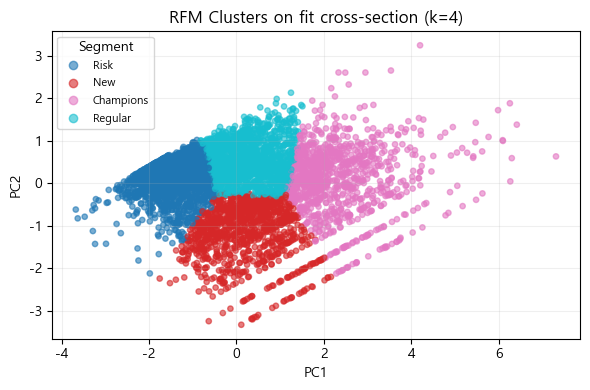

PCA 설명분산: [0.74  0.209] | 누적: 0.949

=== PCA 로딩 ===
             PC1    PC2
Recency   -0.485  0.874
Frequency  0.621  0.320
Monetary   0.616  0.365


In [16]:
# ============================================================
# 19-D. PCA 시각화 (fit 단면, 최종 모델 기준)
# ============================================================
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_FIT)

plt.figure(figsize=(6, 4))
sc = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=segment_kmeans.labels_,
                 cmap='tab10', alpha=0.6, s=15)
plt.xlabel('PC1'); plt.ylabel('PC2')
plt.title(f'RFM Clusters on fit cross-section (k={N_CLUSTERS})')
plt.legend(sc.legend_elements()[0],
           [panel_cluster_name_map[i] for i in range(N_CLUSTERS)],
           title='Segment', fontsize=8)
plt.grid(alpha=0.2)
plt.tight_layout(); plt.show()

print('PCA 설명분산:', pca.explained_variance_ratio_.round(3),
      '| 누적:', pca.explained_variance_ratio_.sum().round(3))

loadings = pd.DataFrame(pca.components_.T, index=segment_features,
                        columns=['PC1', 'PC2'])
print('\n=== PCA 로딩 ===')
print(loadings.round(3))

In [17]:
print([c for c in panel_model.columns if 'cluster' in c or 'Segment' in c])

['cluster', 'Segment']


In [18]:
print(pd.DataFrame(segment_kmeans.cluster_centers_, columns=segment_features)
      .assign(Segment=lambda d: d.index.map(panel_cluster_name_map)).round(3))

   Recency  Frequency  Monetary    Segment
0    0.814     -0.826    -0.887       Risk
1   -1.102     -0.330    -0.195        New
2   -1.034      1.579     1.395  Champions
3    0.389      0.278     0.394    Regular


,Recency,Frequency,Monetary
cluster,,,
0,0.814,-0.826,-0.887
1,-1.102,-0.331,-0.197
2,-1.034,1.579,1.395
3,0.388,0.278,0.394


cluster
0    2046
1    1062
2    1033
3    1478
Name: count, dtype: int64
2011-10 단면 고객 수: 5619
그림 조건: k=4 | fit=2011-10 | snapshot=2011-10


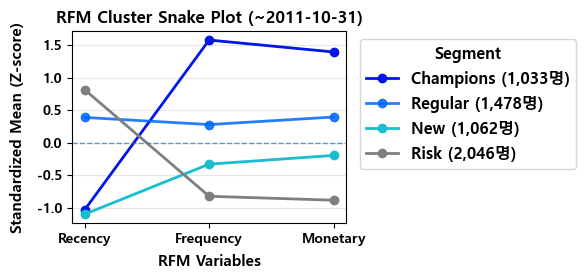

In [19]:
import matplotlib.pyplot as plt

SNAPSHOT = pd.Period('2011-10', 'M')
SNAPSHOT_END = SNAPSHOT.to_timestamp(how='end').strftime('%Y-%m-%d')

snap_mask = segment_mask & (panel_model['YearMonth'] == SNAPSHOT)
assert snap_mask.sum() > 0, f'{SNAPSHOT} 단면이 비어 있음'

seg_snap = np.log1p(panel_model.loc[snap_mask, segment_features].astype(float))
display_scaler = StandardScaler().fit(seg_snap)
X_SNAP_Z = display_scaler.transform(seg_snap)
snap_cluster = panel_model.loc[snap_mask, 'cluster'].astype(int)

snake_mean = (pd.DataFrame(X_SNAP_Z, columns=segment_features)
              .assign(cluster=snap_cluster.to_numpy())
              .groupby('cluster')[segment_features].mean())
cluster_counts = snap_cluster.value_counts().sort_index()

display(snake_mean.round(3))
print(cluster_counts)
print(f'{SNAPSHOT} 단면 고객 수:', len(snap_cluster))
print(f'그림 조건: k={N_CLUSTERS} | fit={SEG_FIT_LAST} | snapshot={SNAPSHOT}')

missing = set(snake_mean.index) - set(panel_cluster_name_map)
assert not missing, f"이름이 지정되지 않은 클러스터: {missing}"

# ── 범례 순서 지정 ────────────────────────────────────
LEGEND_ORDER = ['Champions', 'Regular', 'New', 'Risk']
name2cluster = {v: k for k, v in panel_cluster_name_map.items()}
plot_order = [name2cluster[n] for n in LEGEND_ORDER if n in name2cluster]
plot_order += [c for c in snake_mean.index if c not in plot_order]

fig, ax = plt.subplots(figsize=(6, 2.9))
x = range(len(segment_features))

COLORS = {'Champions': "#0017e6",   # 보라-파랑 중간
          'Regular':   "#0066ffda",
          'New':       'tab:cyan',
          'Risk':      'tab:gray'}
ORDER  = ['Champions', 'New', 'Regular', 'Risk']

for c in plot_order:
    name = panel_cluster_name_map[c]
    ax.plot(x, snake_mean.loc[c, segment_features], marker='o', linewidth=2,
            color=COLORS[name],
            label=f'{name} ({cluster_counts.loc[c]:,}명)')

ax.axhline(0, linestyle='--', linewidth=1, alpha=0.7)
ax.set_xticks(list(x)); ax.set_xticklabels(segment_features)
ax.set_ylabel('Standardized Mean (Z-score)')
ax.set_xlabel('RFM Variables')
ax.set_title(f'RFM Cluster Snake Plot (~{SNAPSHOT_END})')

leg = ax.legend(title='Segment', bbox_to_anchor=(1.02, 1), loc='upper left',
                prop={'weight': 'bold', 'size': 11.5})
leg.get_title().set_fontsize(11.5)
leg.get_title().set_fontweight('bold')

ax.tick_params(labelsize=10)
for lbl in ax.get_xticklabels() + ax.get_yticklabels():
    lbl.set_fontweight('bold')
ax.set_xlabel(ax.get_xlabel(), fontsize=11, fontweight='bold', labelpad=6)
ax.set_ylabel(ax.get_ylabel(), fontsize=11, fontweight='bold', labelpad=8)
ax.set_title(ax.get_title(), fontsize=12, fontweight='bold')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(r'C:\Users\rladp\Desktop\fig2.png', dpi=300, bbox_inches='tight')
plt.show()

In [20]:
km10 = KMeans(n_clusters=N_CLUSTERS, random_state=RANDOM_STATE, n_init=10).fit(X_SNAP_Z)
print('ARI:', adjusted_rand_score(snap_cluster.to_numpy(), km10.labels_))

ARI: 1.0


In [21]:
nan_rows = panel_model[
    panel_model['Segment'].isna()
].copy()

print("NaN 행 수:", len(nan_rows))

print(
    nan_rows[
        ['Recency', 'Frequency', 'Monetary']
    ].describe()
)

print("\n제외 원인")
print({
    'Recency 결측': nan_rows['Recency'].isna().sum(),
    'Recency 음수': (nan_rows['Recency'] < 0).sum(),
    'Frequency 0 이하': (nan_rows['Frequency'] <= 0).sum(),
    'Monetary 0 이하': (nan_rows['Monetary'] <= EPSILON).sum()
})

NaN 행 수: 273
          Recency   Frequency     Monetary
count  273.000000  273.000000   273.000000
mean   202.282051    1.267399  -178.581502
std    157.256737    0.746265   467.010587
min      0.000000    1.000000 -1663.060000
25%     75.000000    1.000000     0.000000
50%    168.000000    1.000000     0.000000
75%    294.000000    1.000000     0.000000
max    699.000000    4.000000     0.000000

제외 원인
{'Recency 결측': np.int64(0), 'Recency 음수': np.int64(0), 'Frequency 0 이하': np.int64(0), 'Monetary 0 이하': np.int64(273)}


Monetary 음수 고객 발생 >  제외

## 재구매 예측 데이터 준비 (T1~T3)

**목표:** 각 고객의 "기준일 이후 4주 내 재구매 확률"을 주차별로 예측하기 위한 학습 데이터 생성

| 셀 | 역할 | 핵심 산출물 |
|----|------|------------|
| **T1** | 재구매 이벤트의 원천이 되는 **고객별 구매일 목록** 준비 | `pdates` (고객→구매일 배열), `purchases` |
| **T2** | 기준시점(origin)마다 **4주 안에 언제 재구매했는지** 라벨링 | `origin_df` (고객 1명 = 1행 + 타깃) |
| **T3** | 각 고객을 **주차별 행(1~4주)으로 확장** (생존분석 포맷) | `pp_train`, `pp_val`, `pp_test` |

### T1 — 구매일 원천
- 원본 `df`에서 정상 구매만 뽑아 **고객별 구매 날짜**를 정리
- `df_train`(10/30까지)이 아니라 **전체 `df`**(12/9까지) 사용 → test 관측창을 채우기 위해

### T2 — 타깃 생성
- origin = 기준월 말일 (예: 2011-09-30)
- 그 **다음날부터 28일** 안의 첫 재구매를 찾아 몇 주차인지(`week_of_repurchase`)와 발생 여부(`event`) 기록
- train/val/test를 **시간순으로 분리** (관측창이 서로 안 겹치게)

### T3 — person-period 확장
- 고객 1명 → 최대 10행(주차별)으로 펴기
- `week`(주차)가 새 피처, `y`(그 주에 샀나 0/1)가 학습 타깃
- **학습용**: 재구매한 주차에서 절단 / **예측용(test)**: 10주 전체
- 이 구조 덕에 누적확률 `1-Π(1-hazard)`이 **단조증가 자동 보장**

In [22]:
# ============================================================
# T1. 재구매 이벤트 원천 (원본 df 사용 — df_train 아님)
# ============================================================
from collections import defaultdict

HORIZON_DAYS = 28
N_WEEKS = 4

purchases = (
    df[df['is_purchase'] & df['Customer ID'].notna()]
    .assign(Customer_ID=lambda d: d['Customer ID'].astype(str),
            Date=lambda d: d['InvoiceDate'].dt.normalize())
    [['Customer_ID', 'Date']]
    .drop_duplicates()
    .sort_values(['Customer_ID', 'Date'])
)

# 고객별 구매일 배열 (빠른 탐색용)
pdates = defaultdict(list)
for cid, d in purchases.itertuples(index=False):
    pdates[cid].append(d)
pdates = {k: np.array(v, dtype='datetime64[ns]') for k, v in pdates.items()}

print("구매일 레코드:", len(purchases))
print("데이터 최종일:", purchases['Date'].max())   # 2011-12-09 여야 함
print("고객 수:", len(pdates))

구매일 레코드: 32878
데이터 최종일: 2011-12-09 00:00:00
고객 수: 5852


In [23]:
# ============================================================
# T2. origin 정의 + 첫 재구매 주차 계산

# ============================================================
ORIGINS = {
    # 8월 말 피처 → 9월 1~28일 정답까지 학습
    'train': pd.period_range('2010-03', '2011-08', freq='M'),

    # 9월 말 피처 → 10월 1~28일 검증
    'val': pd.PeriodIndex(['2011-09'], freq='M'),

    # 10월 말 피처 → 11월 1~28일 테스트
    'test': pd.PeriodIndex(['2011-10'], freq='M'),
}
def build_target(origin_period, split_name):
    rows = panel_model[panel_model['YearMonth'] == origin_period].copy()
    if len(rows) == 0:
        return None
    origin_end = origin_period.to_timestamp(how='end').normalize()
    win_start = origin_end + pd.Timedelta(days=1)
    win_end_exclusive = win_start + pd.Timedelta(days=HORIZON_DAYS)

    weeks, events = [], []
    for cid in rows['Customer ID'].astype(str):
        arr = pdates.get(cid)
        if arr is None:
            weeks.append(np.nan); events.append(0); continue
        nxt = arr[
    (arr >= np.datetime64(win_start)) &
    (arr < np.datetime64(win_end_exclusive))
]
        if len(nxt) == 0:
            weeks.append(np.nan); events.append(0)
        else:
            gap = (pd.Timestamp(nxt[0]) - origin_end).days
            weeks.append(int(np.ceil(gap / 7)))   # 28일이면 1~4주
            events.append(1)

    rows['week_of_repurchase'] = weeks
    rows['event'] = events
    rows['origin'] = str(origin_period)
    rows['split'] = split_name
    return rows

parts = []
for split, periods in ORIGINS.items():
    for p in periods:
        r = build_target(p, split)
        if r is not None:
            parts.append(r)

origin_df = pd.concat(parts, ignore_index=True)

# Segment NaN(Monetary<=0) 제외 — CatBoost 범주형 NaN 방지
origin_df = origin_df[origin_df['Segment'].notna()].reset_index(drop=True)

print("origin 행 수:", len(origin_df))
print("\nsplit별 행 수 / 이벤트율")
print(origin_df.groupby('split').agg(
    n=('event','size'), event_rate=('event','mean')).round(3))
print("\ntest 주차별 첫 재구매 분포")
print(origin_df[origin_df['split']=='test']['week_of_repurchase']
      .value_counts().sort_index())

origin 행 수: 82091

split별 행 수 / 이벤트율
           n  event_rate
split                   
test    5619       0.247
train  71071       0.202
val     5401       0.195

test 주차별 첫 재구매 분포
week_of_repurchase
1.0    400
2.0    401
3.0    362
4.0    227
Name: count, dtype: int64


In [24]:
# ============================================================
# T3. person-period 확장
#   학습용: 이벤트 주차에서 절단 / 예측용: 10주 전체 그리드
# ============================================================
def expand_pp(d, n_weeks=N_WEEKS, truncate=True):
    d = d.reset_index(drop=True).copy()
    d['last_week'] = (np.where(d['event'] == 1, d['week_of_repurchase'], n_weeks)
                      if truncate else n_weeks)
    d['last_week'] = d['last_week'].astype(int)

    pp = d.loc[d.index.repeat(d['last_week'])].copy()
    pp['week'] = pp.groupby(level=0).cumcount() + 1
    pp['y'] = ((pp['event'] == 1) &
               (pp['week'] == pp['week_of_repurchase'])).astype(int)

    # 해당 주가 속한 달력 월 (성수기 포착)
    oe = pd.PeriodIndex(pp['origin'].values, freq='M').to_timestamp(how='end')
    pp['pred_month'] = np.asarray(
        (oe + pd.to_timedelta(np.asarray(pp['week']) * 7, unit='D')).month)
    return pp.reset_index(drop=True)

pp_train = expand_pp(origin_df[origin_df['split'] == 'train'])
pp_val   = expand_pp(origin_df[origin_df['split'] == 'val'])
pp_test  = expand_pp(origin_df[origin_df['split'] == 'test'], truncate=False)

print("train pp:", len(pp_train), "| hazard:", pp_train['y'].mean().round(4))
print("val   pp:", len(pp_val),   "| hazard:", pp_val['y'].mean().round(4))
print("test  pp:", len(pp_test), "(=", len(origin_df[origin_df['split']=='test'])*N_WEEKS, ")")

train pp: 260439 | hazard: 0.0551
val   pp: 19847 | hazard: 0.053
test  pp: 22476 (= 22476 )


칼럼 정의

| 칼럼                | 의미                | 계산 기준                              | 모델에서 기대하는 역할                        |
| ----------------- | ----------------- | ---------------------------------- | ----------------------------------- |
| `Recency`         | 마지막 정상 구매 후 경과 일수 | 기준월 말일 − 최근 구매일                    | 최근 구매한 고객인지, 오래 쉬고 있는 고객인지 구분       |
| `Frequency`       | 기준월까지의 누적 주문 횟수   | 정상 구매 Invoice 수의 누적합               | 반복 구매가 많은 고객인지 측정                   |
| `Monetary`        | 기준월까지의 누적 순매출     | 월별 순매출의 누적합                        | 고객의 누적 구매 가치 측정                     |
| `sales_m0`     | **기준월의 순매출**      | 현재 `YearMonth`의 `monthly_sales`    | 가장 최근 월의 구매금액                       |
| `sales_m1`     | 기준월 직전 월의 순매출     | `monthly_sales.shift(1)`           | 1개월 전 구매금액                          |
| `sales_m2`     | 기준월 2개월 전의 순매출    | `monthly_sales.shift(2)`           | 2개월 전 구매금액                          |
| `orders_m0`    | **기준월의 주문 횟수**    | 현재 `YearMonth`의 `monthly_orders`   | 가장 최근 월의 구매 빈도                      |
| `orders_m1`    | 기준월 직전 월의 주문 횟수   | `monthly_orders.shift(1)`          | 1개월 전 구매 빈도                         |
| `orders_m2`    | 기준월 2개월 전 주문 횟수   | `monthly_orders.shift(2)`          | 2개월 전 구매 빈도                         |
| `quantity_m0`  | **기준월의 순수량**      | 현재 `YearMonth`의 `monthly_quantity` | 최근 월의 구매·반품 수량 규모                   |
| `customer_tenure` | 첫 구매 이후 활동 개월 수   | 기준월 − 최초 구매월                       | 신규 고객인지 장기 고객인지 구분                  |
| `month`           | 기준월의 월 번호         | `YearMonth.dt.month`               | 계절성 반영. 현재는 주석 처리되어 모델에서 제외         |
| `Segment`         | RFM 기반 고객군        | K-Means로 RFM을 4개 군집화               | Champions, Lost, At Risk 등 고객 상태 반영 |
| `week`            | 예측 기간의 주차         | 1, 2, 3, 4                         | 몇 주차의 재구매 확률인지 알려주는 시간축             |
| `pred_month`      | 기준월 다음 달의 월 번호    | origin 월의 다음 달     | 예측 기간이 5주 이상일 때 의미가 있음             |


추가 변수  
| 요청 | 칼럼명 | 정의/주의 |
|---|---|---|
| 평균 주문금액 | `avg_order_value` | 누적 순매출 ÷ 누적 주문수(net 기준) |
| 최근 30일 매출 | `sales_30d` | 최근 완료 1개 캘린더월 매출(`sales_m0`), 실제 30일의 근사값 |
| 최근 90일 매출 | `sales_90d` | 최근 완료 3개 캘린더월 매출 합(`lag_1 + lag_2 + lag_3`), 실제 90일의 근사값 |
| 최근 주문금액 | `last_order_value` | 기준시점까지 발생한 주문 중 **가장 최근 1건의 주문금액, 주문이 없는 달은 직전 주문금액 유지(ffill) |
| 최대 주문금액 | `max_order_value` | 기준시점까지 발생한 **전체 주문 중 가장 큰 주문금액(as-of 누적 최댓값) |
| 주문금액 표준편차 | `std_order_value` | 기준시점까지 주문금액의 표본표준편차, 주문 2건 미만은 0 |
| 최근 매출 추세 | `sales_trend_1m` | 최근 완료 월 매출 − 직전 월 매출(`lag_1 - lag_2`) |
| 평균 구매수량 | `avg_purchase_qty` | 누적 구매수량 ÷ 누적 주문수, 즉 주문당 평균 구매수량 |
| 활동기간당 매출 | `sales_per_tenure` | 누적 순매출 ÷ `(customer_tenure + 1)`, 첫 구매 이후 경과 월당 매출 |

In [25]:
# T3.5
FEATS = ['Recency','Frequency','Monetary',
         'sales_m0','sales_m1','sales_m2',
         'orders_m0','orders_m1','orders_m2',
         'quantity_m0','customer_tenure', 'Segment','week','pred_month', 'month', 
         # ── 추가 파생 피처 9개 (모델 학습 때 선택) ──
         'avg_order_value','sales_30d','sales_90d',
         'last_order_value','max_order_value','std_order_value',
         'sales_trend_1m','avg_purchase_qty','sales_per_tenure',
         # ── 취소 주문 건수 ──
         'cancel_cnt','cancel_m0'
         ]

# Customer ID: 고객 식별자
# origin: 피처를 계산한 기준월
# split: train / val / test 구분
KEYS  = ['Customer ID','origin','split']

# | 칼럼                   | 의미               | 현재 person-period 모델에서 역할 |
# | -------------------- | ---------------- | ------------------------ |
# | `y`                  | 해당 주차에 최초 재구매했는지 | **실제 모델 정답**             |
# | `event`              | 향후 4주 내 재구매했는지   | 고객 단위 보조 정답              |
# | `week_of_repurchase` | 최초 재구매가 몇 주차인지   | `y` 생성용 보조 정답            |
LABEL = ['y','event','week_of_repurchase']

KEEP = KEYS + FEATS + LABEL

LEAK = ['target_next_purchase','target_next_sales','next_month_orders',
        'last_week','monthly_last_purchase','last_purchase_date','month_end']#최종 피처를 만들기 위한 중간 재료이거나, 정답에 해당하는 칼럼
assert not set(LEAK) & set(KEEP), '누출 컬럼 잔존'


In [26]:
# ============================================================
# 15. 최종 산출물 저장 (모든 패널 + 재구매 타깃)
# ============================================================


export_cols = [
    'Customer ID','YearMonth','Recency','Frequency','Monetary','Segment',
    'sales_m0','sales_m1','sales_m2',
    'orders_m0','orders_m1','orders_m2',
    'quantity_m0','customer_tenure','month',
    'target_next_sales','target_next_purchase'
]
lag_cols = ['sales_m0','sales_m1','sales_m2',
            'orders_m0','orders_m1','orders_m2','quantity_m0']
money_cols = ['Monetary','sales_m0','sales_m1','sales_m2','target_next_sales']



# ── (A) 월별 분석 패널 ──────────────────────────────
cmp_ = panel_model[export_cols].sort_values(['Customer ID','YearMonth']).reset_index(drop=True)
cmp_[lag_cols] = cmp_[lag_cols].fillna(0)
cmp_[money_cols] = cmp_[money_cols].round(2)
cmp_['quantity_m0'] = cmp_['quantity_m0'].round(6)
cmp_ = cmp_.dropna(subset=['Segment']).reset_index(drop=True)


# ── 검증 ──────────────────────────────────────────
print('\n월별 패널 기간:', cmp_['YearMonth'].min(), '~', cmp_['YearMonth'].max())
print('세그먼트 분포\n', cmp_['Segment'].value_counts())
print('\norigin split별\n', origin_df.groupby('split')['event'].agg(['size','mean']).round(3))


월별 패널 기간: 2009-12 ~ 2011-10
세그먼트 분포
 Segment
Risk         31210
New          23182
Regular      19958
Champions    11677
Name: count, dtype: int64

origin split별
         size   mean
split              
test    5619  0.247
train  71071  0.202
val     5401  0.195


In [27]:
import pandas as pd
chk = pd.read_parquet('data/processed/pp_train.parquet')
print(chk.shape)                    # (260439, 21)
print(sorted(set(LEAK) & set(chk.columns)))   # []

(260439, 30)
[]


In [28]:
tmp = tx.copy()
tmp['first_pm'] = tmp['Customer ID'].map(first_purchase_month)

no_purchase = tmp['first_pm'].isna()                    # 구매 없이 취소만 있는 고객
before_first = ~no_purchase & (tmp['YearMonth'] < tmp['first_pm'])

print('구매이력 없는 고객:', round(tmp.loc[no_purchase,'Sales'].sum(),2),
      '| 고객수', tmp.loc[no_purchase,'Customer ID'].nunique())
print('첫구매 이전 취소:', round(tmp.loc[before_first,'Sales'].sum(),2))
print('합계:', round(tmp.loc[no_purchase|before_first,'Sales'].sum(),2))
# 구매 이력이 없는 취소 전용 고객 23명과 첫 구매월 이전 반품 건은 패널에서 제외했으며, 이는 전체 순매출의 0.03% 수준이다.

구매이력 없는 고객: -1406.13 | 고객수 23
첫구매 이전 취소: -3325.17
합계: -4731.3


In [29]:
# T3 실행 후
print("train pp:", len(pp_train), "| hazard:", pp_train['y'].mean().round(4))
print("val   pp:", len(pp_val),   "| hazard:", pp_val['y'].mean().round(4))
print("test  pp:", len(pp_test), "(=", len(origin_df[origin_df['split']=='test'])*N_WEEKS, ")")


train pp: 260439 | hazard: 0.0551
val   pp: 19847 | hazard: 0.053
test  pp: 22476 (= 22476 )


In [30]:
# ============================================================
# T3.5 Person-period 데이터 저장
# ============================================================
import pandas as pd
from pathlib import Path



assert not set(LEAK) & set(KEEP), '누출 컬럼 잔존'


# ------------------------------------------------------------
# 저장 경로
# ------------------------------------------------------------
OUT = Path('data/processed')
OUT.mkdir(parents=True, exist_ok=True)


# ------------------------------------------------------------
# Parquet + CSV 저장 함수
# ------------------------------------------------------------
def save_pq(d, name, cols=KEEP, csv=True):
    save_df = d[
        [c for c in cols if c in d.columns]
    ].copy()

    # Period 자료형은 문자열로 변환
    for c in save_df.columns:
        if isinstance(save_df[c].dtype, pd.PeriodDtype):
            save_df[c] = save_df[c].astype(str)

    # Parquet 저장
    parquet_path = OUT / f'{name}.parquet'
    save_df.to_parquet(parquet_path, index=False)

    # CSV 저장
    if csv:
        csv_path = OUT / f'{name}.csv'

        save_df.to_csv(
            csv_path,
            index=False,
            encoding='utf-8-sig'
        )

    print(
        f'[{name}]\n'
        f'행: {len(save_df):,}\n'
        f'열: {save_df.shape[1]}\n'
        f'CSV: {csv_path if csv else "저장 안 함"}\n'
        f'Parquet: {parquet_path}\n'
    )


# ------------------------------------------------------------
# 데이터 저장
# ------------------------------------------------------------
save_pq(origin_df, 'repurchase_origin')
save_pq(pp_train, 'pp_train')
save_pq(pp_val, 'pp_val')
save_pq(pp_test, 'pp_test')

[repurchase_origin]
행: 82,091
열: 29
CSV: data\processed\repurchase_origin.csv
Parquet: data\processed\repurchase_origin.parquet

[pp_train]
행: 260,439
열: 32
CSV: data\processed\pp_train.csv
Parquet: data\processed\pp_train.parquet

[pp_val]
행: 19,847
열: 32
CSV: data\processed\pp_val.csv
Parquet: data\processed\pp_val.parquet

[pp_test]
행: 22,476
열: 32
CSV: data\processed\pp_test.csv
Parquet: data\processed\pp_test.parquet



In [31]:
# 1) net-sales로 상계 안 되는 잔여 반품 (고객 순매출이 음수로 남는 케이스)
cust_net = df[df['Customer ID'].notna()].groupby('Customer ID')['Sales'].sum()
print("순매출 음수 고객:", (cust_net < 0).sum(), "명 / 순매출합:", round(cust_net[cust_net<0].sum(),2))

# 2) C 아닌데 순수량 0 이하로 떨어진 인보이스 (Frequency 오염원)
inv_qty = df[df['Customer ID'].notna()].groupby('Invoice')['Quantity'].sum()
non_c = ~inv_qty.index.astype(str).str.startswith('C')
print("전액상쇄 비취소 인보이스:", (non_c & (inv_qty<=0)).sum(), "건")

# 3) 취소인데 대응 원구매 자체가 없는 고객 (orphan 성격)
has_purchase = df[df['is_purchase']].groupby('Customer ID').size()
cancel_cust = df[df['is_cancel']].groupby('Customer ID').size()
orphan_cust = set(cancel_cust.index) - set(has_purchase.index)
print("구매 없이 취소만 있는 고객:", len(orphan_cust), "명")

순매출 음수 고객: 28 명 / 순매출합: -2965.59
전액상쇄 비취소 인보이스: 0 건
구매 없이 취소만 있는 고객: 23 명


In [32]:
# 순매출 음수 28명 추출
cust_net = df[df['Customer ID'].notna()].groupby('Customer ID')['Sales'].sum()
neg_ids = cust_net[cust_net < 0].index

sub = df[df['Customer ID'].isin(neg_ids)].copy()
# YearMonth 없으면 생성
if 'YearMonth' not in sub.columns:
    sub['YearMonth'] = sub['InvoiceDate'].dt.to_period('M')

# 고객별: 첫 거래월 / 마지막 거래월 / 취소가 발생한 월 / 순매출
summary = sub.groupby('Customer ID').agg(
    첫월=('YearMonth', 'min'),
    끝월=('YearMonth', 'max'),
    순매출=('Sales', 'sum'),
).round(2)
summary['취소월'] = sub[sub['is_cancel']].groupby('Customer ID')['YearMonth'] \
    .apply(lambda s: sorted(s.unique().astype(str)))
print(summary.to_string())

# 첫 거래월 분포 (시작월 경계에 몰렸는지 확인)
print("\n=== 첫 거래월 분포 ===")
print(sub.groupby('Customer ID')['YearMonth'].min().value_counts().sort_index())

                  첫월       끝월      순매출                 취소월
Customer ID                                               
12896        2009-12  2009-12   -29.75           [2009-12]
13091        2009-12  2011-11 -1343.24  [2009-12, 2011-11]
13112        2009-12  2010-06    -5.44  [2009-12, 2010-06]
13163        2010-02  2010-04   -10.00           [2010-02]
13342        2010-05  2010-05   -14.10           [2010-05]
13353        2010-11  2010-11   -28.85           [2010-11]
13749        2010-01  2010-01   -10.25           [2010-01]
14120        2010-10  2010-10   -23.80           [2010-10]
14213        2010-10  2010-12    -0.00           [2010-12]
14337        2009-12  2009-12  -658.63           [2009-12]
14763        2009-12  2009-12    -9.95           [2009-12]
14864        2009-12  2009-12   -48.75           [2009-12]
14914        2010-04  2010-04    -5.85           [2010-04]
14925        2009-12  2009-12    -7.95           [2009-12]
15767        2009-12  2010-03  -242.70  [2009-12, 2010-0

In [33]:
mid_ids = summary.index[summary['첫월'].astype(str) >= '2010-01']  # 2009-12 아닌 11명
show = df[df['Customer ID'].isin(mid_ids)].copy()
show['YearMonth'] = show['InvoiceDate'].dt.to_period('M')
cols = ['Customer ID','Invoice','StockCode','Quantity','Price','Sales','InvoiceDate']
# price_raw 있으면 같이
if 'Price_raw' in show.columns: cols.insert(5,'Price_raw')
print(show.sort_values(['Customer ID','InvoiceDate'])[cols].to_string())

       Customer ID  Invoice StockCode  Quantity  Price  Price_raw   Sales         InvoiceDate
70173        13163  C498609     84685        -1   3.75       3.75   -3.75 2010-02-21 16:22:00
70174        13163  C498609     21276        -2   6.95       6.95  -13.90 2010-02-21 16:22:00
113494       13163   503953     21276         2   1.95       6.95    3.90 2010-04-08 16:21:00
113495       13163   503953     84685         1   3.75       3.75    3.75 2010-04-08 16:21:00
140571       13342  C507204     21532        -2   2.10       2.10   -4.20 2010-05-06 16:44:00
140572       13342  C507204     21534        -2   4.95       4.95   -9.90 2010-05-06 16:44:00
363940       13353  C533099     22890        -1   9.95       9.95   -9.95 2010-11-16 11:14:00
363941       13353  C533099     21843        -1  10.95      10.95  -10.95 2010-11-16 11:14:00
363942       13353  C533099     22840        -1   7.95       7.95   -7.95 2010-11-16 11:14:00
33807        13749  C493864    85226A        -5   0.55      

In [ ]:
# 14213 전체 거래 (필터 없이 df 전체에서)
c = df[df['Customer ID'].astype(str).str.replace('.0','',regex=False) == '14213'].copy()
c['YearMonth'] = c['InvoiceDate'].dt.to_period('M')

cols = ['Invoice','StockCode','Quantity','Price','Sales','InvoiceDate']
if 'Price_raw' in c.columns: cols.insert(4,'Price_raw')

print("14213 총 행 수:", len(c))
print("14213 순매출 합:", round(c['Sales'].sum(), 2))
print()
print(c.sort_values('InvoiceDate')[cols].to_string())

14213 총 행 수: 10
14213 순매출 합: -0.0

        Invoice StockCode  Quantity  Price  Price_raw  Sales         InvoiceDate
332083   529803     22580        48   4.95       4.95  237.6 2010-10-31 10:37:00
332084   529803     22689        50   6.75       6.75  337.5 2010-10-31 10:37:00
332085   529803     22942        48   7.65       7.65  367.2 2010-10-31 10:37:00
332086   529803     22186        48   2.55       2.55  122.4 2010-10-31 10:37:00
332087   529803     22591        50   2.55       2.55  127.5 2010-10-31 10:37:00
398442  C536850     22942       -48   7.65       7.65 -367.2 2010-12-03 09:47:00
398443  C536850     22689       -50   6.75       6.75 -337.5 2010-12-03 09:47:00
398444  C536850     22591       -50   2.55       2.55 -127.5 2010-12-03 09:47:00
398445  C536850     22580       -48   4.95       4.95 -237.6 2010-12-03 09:47:00
398446  C536850     22186       -48   2.55       2.55 -122.4 2010-12-03 09:47:00


: 